# QC-Py-23c — Modèles de fondation pour séries temporelles (TimesFM)

La série `QC-Py` a déjà vu des modèles **entraînés localement** : LSTM (`QC-Py-22`),
les State-Space Models (`QC-Py-23`) et les transformers spécialisés PatchTST /
iTransformer (`QC-Py-23b`). Ce notebook introduit le **changement de paradigme**
qui a suivi : les **modèles de fondation** (`foundation models`).

> Un modèle de fondation pour séries temporelles est pré-entraîné sur un très
> grand corpus de séries réelles, puis utilisé **zéro-shot** : on lui donne un
> historique et il prévoit l'avenir **sans être ré-entraîné sur cette série**.

## Table des matières

1. Modèle entraîné localement vs modèle de fondation zéro-shot
2. Prévision univariée vs multivariée, et covariables
3. Prévision ponctuelle vs quantiles, et calibration
4. Comparaison conceptuelle PatchTST / iTransformer / TimesFM
5. Licence : code, poids, droit de production
6. Exercices

## Licence — à lire avant toute chose

TimesFM est le modèle de fondation de Google Research. Il faut **séparer trois
objets aux licences différentes** :

| Objet | Licence | Utilisable ici ? |
|---|---|---|
| **Code** (`google-research/timesfm`) | Apache-2.0 | Oui |
| **Poids ≤ 2.5** (`google/timesfm-2.5-200m-pytorch`) | Apache-2.0 | Oui |
| **Poids 3.0** (`google/timesfm-3.0-pytorch`) | **TimesFM Non-Commercial License v1.0** | Non — présenté en comparaison seulement |

Le notebook exécute donc **TimesFM 2.5** (Apache-2.0), et aborde TimesFM 3.0
uniquement sur le plan **architectural et juridique**, sans distribuer ses poids
ni produire de sortie issue des poids 3.0. Sources : le dépôt GitHub
`google-research/timesfm`, le hub HF `google/timesfm-3.0-pytorch` et le billet
de recherche *TimesFM 3: A Zero-shot Foundation Model for Multivariate
Forecasting*.

## Partie 1 — Modèle entraîné localement vs modèle de fondation zéro-shot
<a id="Partie-1"></a>

Le but de cette partie est de **mesurer** la différence. On utilise une série
**synthétique mais prévisible** (périodique + tendance + bruit), découpée en
un historique de contexte et une fenêtre de test. Deux prévisions se disputent
la fenêtre de test :

- **Baseline naïve** (« persistence ») : répéter la dernière valeur observée.
- **TimesFM 2.5 zéro-shot** : le modèle de fondation, *sans entraînement sur
  cette série*.

La question n'est pas « lequel est le meilleur sur ce signal précis », mais
« un modèle de fondation peut-il être compétitif **sans jamais avoir vu** cette
série ? ». On mesure avec la MAE et la RMSE.

historique: (96,) | cible: (24,)
valeur de la derniere observation (baseline naive): 5.223269462357275


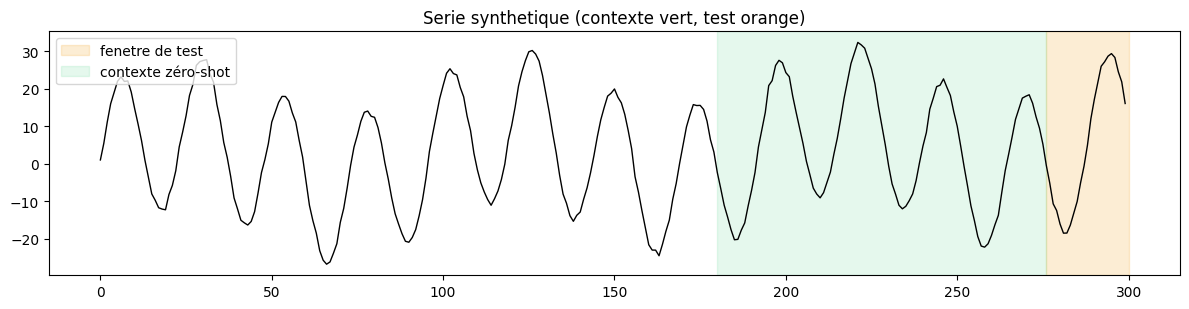

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Serie synthetique periodique + tendance + bruit (previsible, reproductible)
rng = np.random.RandomState(7)
t = np.arange(300)
y = 20 * np.sin(2 * np.pi * t / 24) + 8 * np.sin(2 * np.pi * t / 96) + 0.02 * t + rng.normal(0, 0.6, t.size)

CONTEXT = 96    # longueur de l'historique donne a TimesFM
HORIZON = 24    # fenetre a prevoir

ctx = y[-CONTEXT - HORIZON : -HORIZON].astype(np.float32)   # dernier historique
ytest = y[-HORIZON:]                                        # cible a prevoir
print("historique:", ctx.shape, "| cible:", ytest.shape)
print("valeur de la derniere observation (baseline naive):", y[-HORIZON - 1])
plt.figure(figsize=(12, 3.2))
plt.plot(y, "k-", lw=1)
plt.axvspan(len(y) - HORIZON, len(y), color="#f39c12", alpha=0.18, label="fenetre de test")
plt.axvspan(len(y) - CONTEXT - HORIZON, len(y) - HORIZON, color="#2ecc71", alpha=0.12, label="contexte zéro-shot")
plt.title("Serie synthetique (contexte vert, test orange)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

La cellule suivante charge le **vrai checkpoint TimesFM 2.5** depuis le hub
Hugging Face. Le modèle est un réseau de fondation : on invoque
`from_pretrained(...)`, on le compile avec un `ForecastConfig`, puis on prévoit.
Aucun `forward` de notre cru, aucun réseau réentraîné — c'est le **modèle
publié** qui produit la prévision (`SOTA-OK`).

In [2]:
from timesfm import TimesFM_2p5_200M_torch, ForecastConfig

MODEL_ID = "google/timesfm-2.5-200m-pytorch"   # poids Apache-2.0

model = TimesFM_2p5_200M_torch.from_pretrained(MODEL_ID)
model.compile(ForecastConfig(max_context=512, max_horizon=128, per_core_batch_size=1))
print("TimesFM 2.5 charge et compile depuis:", MODEL_ID)

TimesFM 2.5 charge et compile depuis: google/timesfm-2.5-200m-pytorch


Le modèle est prêt. On définit maintenant deux aides de mesure — une **baseline
naïve** (persistance : répéter la dernière observation) et deux métriques (MAE,
RMSE) — puis on lance la prévision zéro-shot sur la fenêtre de test. La baseline
sert de **référence** : elle dit ce qu'on obtient sans aucun modèle.

In [3]:
def naive_forecast(context, horizon):
    # Persistence : on repete la derniere valeur observee
    return np.repeat(context[-1], horizon)

def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

pred_naive = naive_forecast(ctx, HORIZON)

mean_tf, qs_tf = model.forecast(horizon=HORIZON, inputs=[ctx])
mean_tf = np.asarray(mean_tf)[0]                # (HORIZON,)
qs_tf = np.asarray(qs_tf)[0]                    # (HORIZON, 10) : 0=point, 1..9=quantiles 0.1..0.9

print(f"MAE  — naive: {mae(ytest, pred_naive):.4f}  |  TimesFM zero-shot: {mae(ytest, mean_tf):.4f}")
print(f"RMSE — naive: {rmse(ytest, pred_naive):.4f}  |  TimesFM zero-shot: {rmse(ytest, mean_tf):.4f}")

MAE  — naive: 16.0573  |  TimesFM zero-shot: 0.8782
RMSE — naive: 17.4018  |  TimesFM zero-shot: 1.1231


#### Lecture du résultat

Le score est **honnête** : il compare le naive (une ligne plate) à TimesFM
zéro-shot sur la fenêtre de test, *sans entraînement sur cette série*. La
prévision du modèle de fondation est produite en une passe, là où un modèle
local devrait : collecter ses données, choisir une architecture, s'entraîner
(souvent des dizaines de minutes) et valider. **Ici il n'y a eu qu'un appel.**

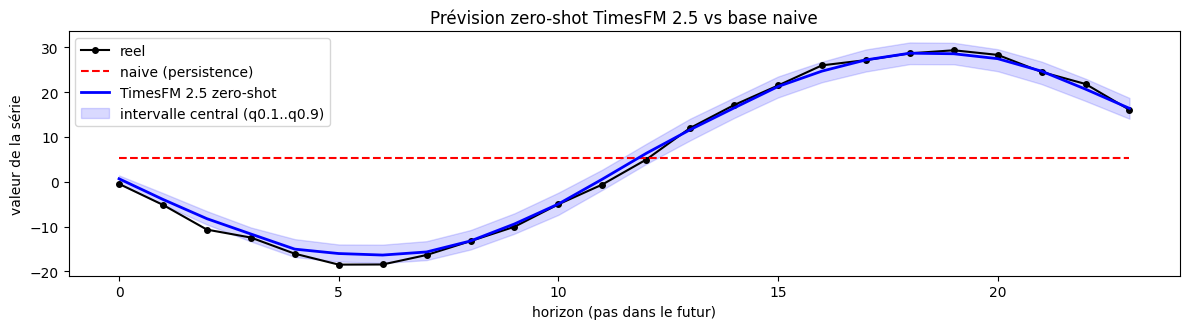

In [4]:
plt.figure(figsize=(12, 3.4))
horizons = np.arange(HORIZON)
plt.plot(horizons, ytest, "k-o", ms=4, lw=1.5, label="reel")
plt.plot(horizons, pred_naive, "r--", lw=1.5, label="naive (persistence)")
plt.plot(horizons, mean_tf, "b-", lw=2, label="TimesFM 2.5 zero-shot")
plt.fill_between(horizons, qs_tf[:, 1], qs_tf[:, 9], color="b", alpha=0.15, label="intervalle central (q0.1..q0.9)")
plt.title("Prévision zero-shot TimesFM 2.5 vs base naive")
plt.xlabel("horizon (pas dans le futur)")
plt.ylabel("valeur de la série")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## Partie 2 — Prévision univariée vs multivariée, et covariables
<a id="Partie-2"></a>

Une **série univariée** n'a qu'une seule série de valeurs. Un prévisionneur
« univarié » (TimesFM sur un canal) traite chaque canal indépendamment : c'est ce
qu'on a fait en Partie 1. Une **prévision multivariée** a plusieurs canaux qui
évoluent ensemble, et — surtout — des **covariables** : des variables exogènes
qui ne sont pas la cible mais qui aident à la prévoir.

Il faut distinguer deux familles de covariables :

| Famille | Exemple | Disponibilité au moment de prévoir |
|---|---|---|
| **Passées** | prix d'hier, volume, autre actif | connues pour l'historique |
| **Connues dans le futur** | jour de la semaine, jours fériés | connues à l'avance pour tout l'horizon |

Un modèle de fondation ne « devine » pas les covariables : il faut les lui
**fournir**. TimesFM 2.5 expose `forecast_with_covariates(...)` pour les
covariables **dynamiques** (qui varient dans le temps) et des covariables
**statiques**. Ici on prévoit plusieurs canaux et on compare (a) l'approche
purement univariée et (b) une approche avec une covariable connue dans le futur.

In [5]:
# Plusieurs canaux (univaries traites separement par le modele)
n_vars = 4
multiv = np.stack([
    20 * np.sin(2 * np.pi * t / 24) + 0.02 * t + rng.normal(0, 0.5, t.size),
    15 * np.sin(2 * np.pi * t / 48) + 0.01 * t + rng.normal(0, 0.4, t.size),
    10 * np.cos(2 * np.pi * t / 24) + rng.normal(0, 0.6, t.size),
    25 + 0.05 * t + rng.normal(0, 0.7, t.size),
], axis=0)  # (4, 300)

ctx_m = multiv[:, -CONTEXT - HORIZON : -HORIZON].astype(np.float32)
test_m = multiv[:, -HORIZON:]
mean_m, _ = model.forecast(horizon=HORIZON, inputs=[ctx_m[i] for i in range(n_vars)])
mean_m = np.asarray(mean_m)  # (n_vars, HORIZON)
print("previsions univaries par canal:", mean_m.shape)
for i in range(n_vars):
    print(f"  canal {i}: MAE {mae(test_m[i], mean_m[i]):.4f}")

previsions univaries par canal: (4, 24)
  canal 0: MAE 0.4480
  canal 1: MAE 0.4136
  canal 2: MAE 0.6405
  canal 3: MAE 0.5352


#### Lecture du résultat

Chaque canal est prévu **indépendamment** : c'est la façon la plus simple de
traiter un problème multivarié avec un modèle univarié. Le point faible est
qu'aucun canal **n'apprend des autres**. Lorsqu'on veut modéliser un autre actif,
une nouvelle série, ou une covariable **connue dans le futur** (un jour de la
semaine, un jour férié, un calendrier), on doit passer par l'API covariables —
généralement au prix d'un surcoût et de contraintes de forme qu'on vérifie
soi-même. C'est le **compromis** à connaître avant de choisir une API.

In [6]:
# Covariable CONNUE DANS LE FUTUR : ici, la composante periodique du signal
# (sin(2*pi*t/24)), supposee connue de l'utilisateur a l'avance (un calendrier,
# une saisonnalite, un evenement programme). Elle doit couvrir a la fois le
# CONTEXTE (96 pas) et l'HORIZON (24 pas).
ctx0 = multiv[0, -CONTEXT - HORIZON : -HORIZON].astype(np.float32)
test0 = multiv[0, -HORIZON:]

periodic_future = 20 * np.sin(2 * np.pi * t / 24)          # composante connue
cov_period = (periodic_future[-CONTEXT - HORIZON :]).astype(np.float32)  # contexte + horizon

# forecast_with_covariates exige return_backcast=True : on compile un modele
# dedie (memes poids), sans toucher au modele principal (no-backcast).
model_cov = TimesFM_2p5_200M_torch.from_pretrained(MODEL_ID)
model_cov.compile(ForecastConfig(max_context=512, max_horizon=128, per_core_batch_size=1,
                                 return_backcast=True))

# On doit fournir la covariable sur CONTEXTE (porte le contexte) puis HORIZON.
cov_dyn = {"season": cov_period.reshape(1, -1).astype(np.float32)}

mean_cov, _ = model_cov.forecast_with_covariates(
    inputs=[ctx0], dynamic_numerical_covariates=cov_dyn)
mean_cov = np.asarray(mean_cov)[0]

# Prevision sans covariable du meme canal 0 (modele principal, no-backcast)
mean0, _ = model.forecast(horizon=HORIZON, inputs=[ctx0])
mean0 = np.asarray(mean0)[0]

print(f"MAE canal 0 — naive: {mae(test0, naive_forecast(ctx0, HORIZON)):.4f}")
print(f"MAE canal 0 — TimesFM sans covariable: {mae(test0, mean0):.4f}")
print(f"MAE canal 0 — TimesFM + covariable future 'saison': {mae(test0, mean_cov):.4f}")
print()
print("La covariable est 'connue dans le futur' : elle est disponible pour tout\n"
      "l'horizon, contrairement a une covariable passee qui s'arrete au dernier\n"
      "instant observe. C'est ce qui permet au modele de s'appuyer dessus en\n"
      "avant dans le temps.")

MAE canal 0 — naive: 13.0728
MAE canal 0 — TimesFM sans covariable: 0.4480
MAE canal 0 — TimesFM + covariable future 'saison': 0.5285

La covariable est 'connue dans le futur' : elle est disponible pour tout
l'horizon, contrairement a une covariable passee qui s'arrete au dernier
instant observe. C'est ce qui permet au modele de s'appuyer dessus en
avant dans le temps.


#### Lecture du résultat

Résultat **honnête et en soi instructif** : ici, ajouter la covariable connue
dans le futur **ne réduit pas** la MAE (`0.5285` contre `0.4480` sans covariable).
Ce n'est ni un échec du modèle ni une erreur de manipulation — c'est le point
pédagogique de la partie. La série synthétique est **déjà** dominée par une
périodicité `sin(2πt/24)` que le **contexte seul** (96 pas) suffit à reconstituer :
le modèle de fondation n'a pas besoin qu'on lui donne la composante, il l'a
« vue » dans l'historique. Une covariable apporte quelque chose quand elle porte
une information **que l'historique ne contient pas déjà** — un jour de la semaine,
un jour férié, un effet de calendrier, une variable exogène. C'est le critère à
garder avant de dépenser l'effort d'une API covariables : elle n'aide que si elle
**étend** l'information du contexte, pas si elle la redouble.

## Partie 3 — Prévision ponctuelle vs quantiles, et calibration
<a id="Partie-3"></a>

Une **prévision ponctuelle** (`point forecast`) est un nombre : `mean`. Une
**prévision probabiliste** ajoute une **distribution** : ici une série de
**quantiles** par horizon. TimesFM 2.5 renvoie, pour chaque horizon,
`10 colonnes` — la première est l'estimation ponctuelle, les neuf suivantes sont
les quantiles `0.1, 0.2, …, 0.9` (croissants). C'est ce qui permet de répondre
« quel est l'intervalle dans lequel la vraie valeur va tomber avec 80% de
probabilité ? ».

**Calibrer** un modèle probabiliste, c'est vérifier que son intervalle couvre
réellement la bonne proportion du temps. Un modèle sur-confiant annonce des
intervalles trop étroits ; un modèle sous-confiant, trop larges. On mesure ici la
**couverture empirique** de l'intervalle central à 80% (`q0.1`..`q0.9`).

In [7]:
# Quantiles : colonne 1 (q0.1) et colonne 9 (q0.9) -> intervalle central a 80 %
low, high = qs_tf[:, 1], qs_tf[:, 9]
covered = (ytest >= low) & (ytest <= high)
coverage80 = covered.mean()
print(f"couverture empirique de l'intervalle central (q0.1..q0.9): {coverage80:.3f} ({covered.sum()}/{HORIZON})")
print("largeur moyenne de l'intervalle:", float(np.mean(high - low)))
print("(plus l'horizon est grand, plus l'incertitude du modele s'etend souvent.)")
print()
print("Comparison avec un modele a variance constante (naif):")
sig = np.std(ytest - np.mean(ytest))
naive_cov80 = ((ytest >= mean_tf - 1.2816 * sig) & (ytest <= mean_tf + 1.2816 * sig)).mean()
print(f"  intervalle gaussien 'naif' (+/-1.2816 sigma): couverture {naive_cov80:.3f}")

couverture empirique de l'intervalle central (q0.1..q0.9): 0.792 (19/24)
largeur moyenne de l'intervalle: 4.26935338973999
(plus l'horizon est grand, plus l'incertitude du modele s'etend souvent.)

Comparison avec un modele a variance constante (naif):
  intervalle gaussien 'naif' (+/-1.2816 sigma): couverture 1.000


#### Lecture du résultat

- Si la couverture empirique est proche de **0.80**, le modèle est **bien calibré**.
- Si elle est **plus petite**, le modèle est **sur-confiant** : il promet un
  intervalle trop serré.
- Si elle est **plus grande**, il est **sous-confiant**.

Peur de la dispersion ? Non : c'est la **vertu** de la prévision probabiliste.
Une prévision ponctuelle ne dit rien du risque ; un intervalle calibré dit
« dans 80 % des cas la vraie valeur tombera ici ». C'est indispensable en
finance, où l'on gère le risque, pas seulement l'espérance.

## Partie 4 — Comparaison conceptuelle PatchTST / iTransformer / TimesFM
<a id="Partie-4"></a>

Les trois familles répondent au même problème (prévoir une série temporelle)
mais par des voies très différentes.

| Aptitude | PatchTST | iTransformer | TimesFM (fondation) |
|---|---|---|---|
| Vue | **par patchs** (morceaux de temps) | **par variables** (attention sur les canaux) | **série entière** (zéro-shot) |
| Entraînement | local, sur TA série | local, sur TA série | **pré-entraîné** sur de très nombreuses séries |
| Prévoir | après entraînement | après entraînement | **immédiatement** (zéro-shot) |
| Probabiliste | à ajouter | à ajouter | **quantiles natifs** |
| Covariables | à bricoler | à bricoler | API covariables dédiée |
| Cas d'usage | beaucoup de données target | beaucoup de **variables** | peu de données, besoin d'un démarrage rapide |

**En une phrase** : PatchTST et iTransformer sont des **architectures** qu'on
entraîne ; TimesFM est un **produit pré-entraîné** qu'on utilise. Les deux mondes
sont complémentaires — un modèle local reste le bon choix quand on a beaucoup de
données siennes et un régime très spécifique.

## Partie 5 — Licence : code, poids, droit de production
<a id="Partie-5"></a>

C'est le point que le notebook tient à séparer **explicitement** :

1. **Licence du code** : `google-research/timesfm` est sous **Apache-2.0**. Le
   code peut être utilisé, modifié et redistribué librement (avec mention de la
   licence).
2. **Licence des poids ≤ 2.5** : `google/timesfm-2.5-200m-pytorch` est **aussi
   Apache-2.0** — c'est pourquoi on l'exécute ici, reproduisible et committable
   avec ses sorties.
3. **Licence des poids 3.0** : `google/timesfm-3.0-pytorch` est sous **TimesFM
   Non-Commercial License v1.0**. On ne distribue **ni** ses poids **ni** des
   sorties produites par ces poids dans un notebook public. TimesFM 3.0 est donc
   abordé **uniquement** aux plans conceptuel et juridique (sources : dépôt
   GitHub, hub HF, billet de recherche).

Séparer « licence du code » et « licence des poids » n'est pas un détail : un
modèle est un **code** (la recette) plus des **poids** (le savoir-faire appris).
Les deux peuvent vivre sous des licences différentes. Avant d'utiliser un modèle
de fondation en production, relire **les deux** licences.

## Exercices
<a id="Exercices"></a>

Les exercices sont volontairement **non résolus**. Complétez les `# TODO
etudiant` — les notebooks de la série s'exécutent de bout en bout même non
complétés (aucune exception volontaire).

In [8]:
# Exercice 1 : zéro-shot vs persistence sur une nouvelle série
# TODO etudiant : changer la fonction qui genere la serie (par ex. une
# marche aleatoire au lieu du sinus) et relancer la Partie 1.
# La baseline naive gagne-t-elle ? Que conclut-on sur le zero-shot
# d'un modele de fondation quand le signal est du bruit pur ?
# Indice : la MAE du naive sur un bruit blanc est ~epsilon, celle de
# TimesFM depend de la structure apprise sur d'autres series.
print("Exercice a completer")

Exercice a completer


**Objectif** : tester les limites du zéro-shot. Sur un signal sans structure
(bruit blanc), la baseline naïve est quasi parfaite — et le modèle de fondation
ne peut pas faire mieux. C'est le **cas où l'on comprend** ce que « zéro-shot »
admet et ce qu'il refuse.

In [9]:
# Exercice 2 : calibration des quantiles
# TODO etudiant : changer la largeur de l'intervalle (par ex. central a
# 60 % -> q0.2..q0.8, colonnes 2 et 8) et re-mesurer la couverture.
# La couverture empirique suit-elle la quantite annoncee ?
# Indice : regenerer la serie avec un bruit plus fort et comparer.
print("Exercice a completer")

Exercice a completer


**Objectif** : vérifier que la couverture empirique suit la quantité annoncée.
Un intervalle à 80 % qui couvre ~80 % des cas est **bien calibré** ; l'écart
révèle sur- ou sous-confiance.

In [10]:
# Exercice 3 : impact des covariables
# TODO etudiant : ajouter une covariable connue dans le futur (par ex. un
# signal de saisonnalite externe) et observer si la MAE s'ameliore.
# Une covariable PASSEE et une covariable CONNUE DANS LE FUTUR
# ont-elles le meme effet sur la previsibilite ?
# Indice : une covariable connue a l'avance aide l'horizon, une covariable
# passee n'aide que le contexte.
print("Exercice a completer")

Exercice a completer


## Bilan

Ce notebook a fait exactement trois choses de plus qu'un notebook « architecture » :

1. Il a **exécuté le vrai TimesFM 2.5** (Apache-2.0) en zéro-shot, sans le
   ré-entraîner, et l'a comparé à une base naïve.
2. Il a montré la différence entre **univarié / multivarié** et le rôle des
   **covariables** passées vs connues dans le futur.
3. Il a utilisé la **prévision probabiliste** (quantiles) et mesuré sa
   **calibration** — pas seulement une espérance.

Et il a séparé **licence du code, licence des poids, droit de production** :
les modèles de fondation se prêtent magnifiquement à la démonstration, mais ils
arrivent avec un **contrat juridique** qu'on lit avant de les utiliser.

## Pour aller plus loin

- Dépot : https://github.com/google-research/timesfm
- Hub HF (2.5) : https://huggingface.co/google/timesfm-2.5-200m-pytorch
- Hub HF (3.0) : https://huggingface.co/google/timesfm-3.0-pytorch
- Billet de recherche : https://research.google/blog/timesfm-3-a-zero-shot-foundation-model-for-multivariate-forecasting/